In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt

In [15]:
# Load and Check file paths


paths = {
    "train": "/content/drive/My Drive/Embedding_Concatenate/Concatenated_Train_embeddings.csv",
    "val":   "/content/drive/My Drive/Embedding_Concatenate/Concatenated_Val_embeddings.csv",
    "test":  "/content/drive/My Drive/Embedding_Concatenate/Concatenated_Test_embeddings.csv"
}

for k,v in paths.items():
    if not os.path.exists(v):
        raise FileNotFoundError(f"Missing: {v}")
print("All files found!")


All files found!


In [16]:
# ------------------------------------------------------
# 2. Remap 23-class labels → 4-class labels (0,1,2,3)
# ------------------------------------------------------
def map_labels(series):
    mapped = []

    for v in series:
        if v == 0:
            mapped.append(0)       # BENIGN
        elif 1 <= v <= 4:
            mapped.append(1)       # DDoS
        elif 5 <= v <= 18:
            mapped.append(2)       # Zero-Day
        elif 19 <= v <= 22:
            mapped.append(3)       # Malware
        else:
            raise ValueError(f"Invalid original label: {v}")

    return np.array(mapped)


# ------------------------------------------------------
# 3. Load original concatenated CSVs
# ------------------------------------------------------
train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])

# ------------------------------------------------------
# 4. Apply label remapping
# ------------------------------------------------------
train_df["Label"] = map_labels(train_df["Label"])
val_df["Label"]   = map_labels(val_df["Label"])
test_df["Label"]  = map_labels(test_df["Label"])

# ------------------------------------------------------
# 5. Save the corrected 4-class CSVs
# ------------------------------------------------------
save_dir = "/content/drive/My Drive/Embedding_Concatenate_4Class"
os.makedirs(save_dir, exist_ok=True)

train_df.to_csv(f"{save_dir}/Train_4class.csv", index=False)
val_df.to_csv(f"{save_dir}/Val_4class.csv", index=False)
test_df.to_csv(f"{save_dir}/Test_4class.csv", index=False)

print("Labels successfully mapped to 0–3 and new CSVs saved!")

Labels successfully mapped to 0–3 and new CSVs saved!


In [17]:
!ls "/content/drive/My Drive/Embedding_Concatenate_4Class"


Test_4class.csv  Train_4class.csv  Val_4class.csv


In [18]:

# Split X and y

train_df = pd.read_csv("/content/drive/My Drive/Embedding_Concatenate_4Class/Train_4class.csv")
val_df   = pd.read_csv("/content/drive/My Drive/Embedding_Concatenate_4Class/Val_4class.csv")
test_df  = pd.read_csv("/content/drive/My Drive/Embedding_Concatenate_4Class/Test_4class.csv")

X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
y_train = train_df["Label"].values.astype(int)

X_val   = val_df.drop(columns=["Label"]).values.astype(np.float32)
y_val   = val_df["Label"].values.astype(int)

X_test  = test_df.drop(columns=["Label"]).values.astype(np.float32)
y_test  = test_df["Label"].values.astype(int)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)


Shapes:
Train: (586532, 384) (586532,)
Val:   (195448, 384) (195448,)
Test:  (195519, 384) (195519,)


In [19]:
# Prepare for ROC

classes = np.array([0, 1, 2, 3])
n_classes = 4
print("Detected classes ({}): {}".format(n_classes, classes))

y_train_bin = label_binarize(y_train, classes=classes)
y_val_bin   = label_binarize(y_val,   classes=classes)
y_test_bin  = label_binarize(y_test,  classes=classes)


Detected classes (4): [0 1 2 3]


In [25]:
# -----------------------------
# Train Random Forest + training time print
# -----------------------------
import time
from sklearn.ensemble import RandomForestClassifier

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    max_depth=20,          # limit depth (prevents overfitting)
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",   # good default for RF
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

rf_model.fit(X_train, y_train)

print(f"\nTraining completed in {time.time() - start:.2f} seconds.")



Training completed in 260.66 seconds.


In [27]:
import joblib
import os

# Directory to save the model
model_dir = "/content/drive/My Drive/Ensemble model training/RandomForest_4Class"
os.makedirs(model_dir, exist_ok=True)

# Save the trained RF model
rf_model_path = os.path.join(model_dir, "random_forest_4class_model.joblib")
joblib.dump(rf_model, rf_model_path)

print("Random Forest model saved to:", rf_model_path)


Random Forest model saved to: /content/drive/My Drive/Ensemble model training/RandomForest_4Class/random_forest_4class_model.joblib


In [28]:
# Predict class probabilities (optional, for ROC)
y_proba = rf_model.predict_proba(X_test)  # shape: (n_samples, 4)

# Predict class labels
y_pred = rf_model.predict(X_test)         # shape: (n_samples,)

# Classification report
print("\nTEST REPORT:\n")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)



TEST REPORT:

              precision    recall  f1-score   support

           0     0.0563    0.0002    0.0003     25519
           1     0.7890    1.0000    0.8821     56715
           2     0.9176    1.0000    0.9570    111324
           3     0.8422    0.9663    0.9000      1961

    accuracy                         0.8692    195519
   macro avg     0.6513    0.7416    0.6849    195519
weighted avg     0.7671    0.8692    0.8098    195519

Confusion matrix:
 [[     4  15168   9992    355]
 [     0  56715      0      0]
 [     1      0 111323      0]
 [    66      0      0   1895]]


In [29]:
# Print Train/Val/Test Reports for Random Forest
def eval_split(name, X, y):
    p = rf_model.predict(X)  # predict returns labels directly
    print(f"\n{name} REPORT:")
    print(classification_report(y, p, digits=4))

# Evaluate
eval_split("TRAIN", X_train, y_train)
eval_split("VAL", X_val, y_val)
eval_split("TEST", X_test, y_test)



TRAIN REPORT:
              precision    recall  f1-score   support

           0     1.0000    0.0085    0.0169     77336
           1     0.7889    1.0000    0.8820    170147
           2     0.9177    1.0000    0.9571    333922
           3     0.8116    1.0000    0.8960      5127

    accuracy                         0.8693    586532
   macro avg     0.8795    0.7521    0.6880    586532
weighted avg     0.8902    0.8693    0.8108    586532


VAL REPORT:
              precision    recall  f1-score   support

           0     0.2632    0.0006    0.0012     25748
           1     0.7892    1.0000    0.8822     56682
           2     0.9176    1.0000    0.9570    111309
           3     0.7366    0.9754    0.8394      1709

    accuracy                         0.8681    195448
   macro avg     0.6766    0.7440    0.6699    195448
weighted avg     0.7926    0.8681    0.8084    195448


TEST REPORT:
              precision    recall  f1-score   support

           0     0.0563    0.0002


===== Confusion Matrix: Train =====
[[   661  45527  29959   1189]
 [     0 170146      1      0]
 [     0      0 333921      1]
 [     0      0      0   5127]]
Saved: /content/drive/My Drive/Ensemble model training/RandomForest_4Class/cm_train.png


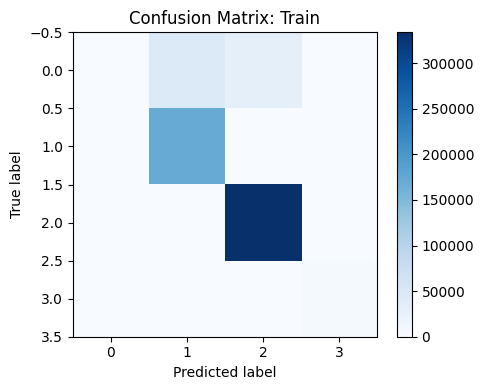


===== Confusion Matrix: Validation =====
[[    15  15143   9996    594]
 [     0  56682      0      0]
 [     0      0 111307      2]
 [    42      0      0   1667]]
Saved: /content/drive/My Drive/Ensemble model training/RandomForest_4Class/cm_val.png


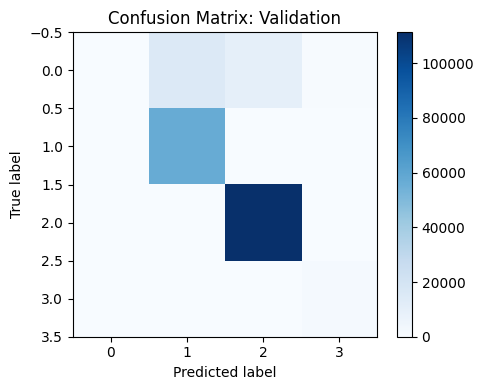


===== Confusion Matrix: Test =====
[[     4  15168   9992    355]
 [     0  56715      0      0]
 [     1      0 111323      0]
 [    66      0      0   1895]]
Saved: /content/drive/My Drive/Ensemble model training/RandomForest_4Class/cm_test.png


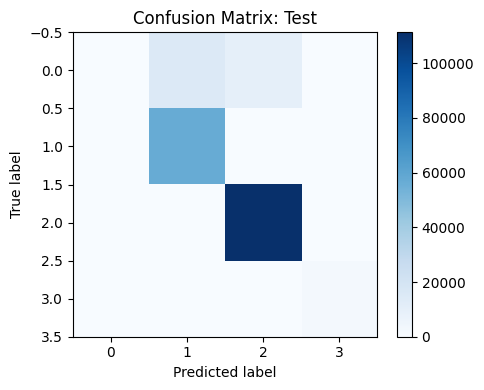

In [30]:
# Confusion Matrix for Train, Validation, and Test (Random Forest)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import os

cm_save_path = "/content/drive/My Drive/Ensemble model training/RandomForest_4Class"
os.makedirs(cm_save_path, exist_ok=True)

def plot_cm_and_save(cm, title, filename):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.tight_layout()

    save_file = f"{cm_save_path}/{filename}"
    plt.savefig(save_file)
    print(f"Saved: {save_file}")
    plt.show()

def generate_cm(name, X, y, filename):
    pred = rf_model.predict(X)  # Random Forest predicts labels directly
    cm = confusion_matrix(y, pred)
    print(f"\n===== Confusion Matrix: {name} =====")
    print(cm)
    plot_cm_and_save(cm, f"Confusion Matrix: {name}", filename)

# Train
generate_cm("Train", X_train, y_train, "cm_train.png")

# Validation
generate_cm("Validation", X_val, y_val, "cm_val.png")

# Test
generate_cm("Test", X_test, y_test, "cm_test.png")


Per-class AUCs:
 Class 0: AUC = 0.6287
 Class 1: AUC = 0.9450
 Class 2: AUC = 0.9400
 Class 3: AUC = 0.9991
Macro AUC: 0.8782133071654702


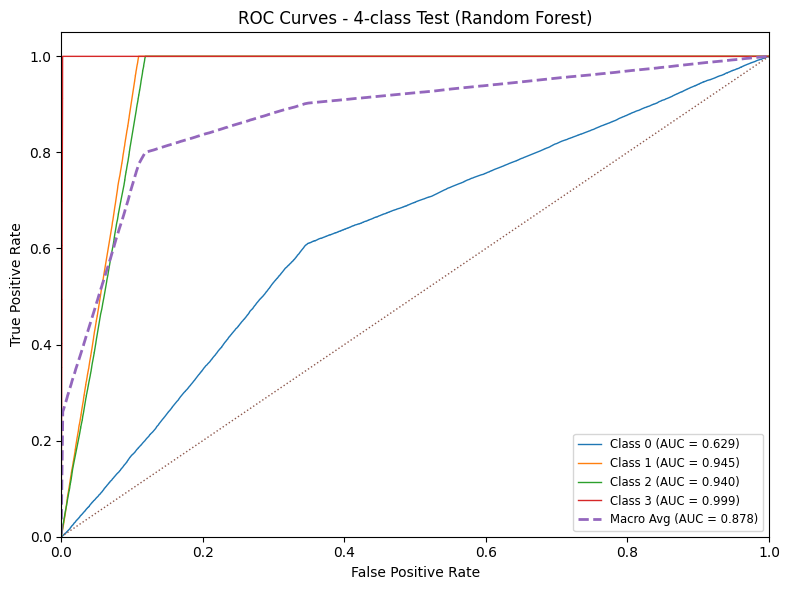

ROC curve saved to: /content/drive/My Drive/Ensemble model training/RandomForest_4Class/roc_curve_test.png


In [31]:
# ROC curves & AUC (one-vs-rest, per-class + macro AUC) for Random Forest

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities
y_proba = rf_model.predict_proba(X_test)  # list of arrays for each class in multi-class

# If multi-class, scikit-learn returns a list of shape (n_samples, n_classes)
# Ensure it's a 2D array: shape (n_samples, n_classes)
if isinstance(y_proba, list):
    y_proba = np.array([p[:, 1] if p.shape[1] == 2 else p for p in y_proba]).T
else:
    y_proba = np.array(y_proba)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print("Per-class AUCs:")
for i in range(n_classes):
    print(f" Class {classes[i]}: AUC = {roc_auc[i]:.4f}")
print("Macro AUC:", roc_auc["macro"])

# Plot ROC
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], linewidth=1,
             label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["macro"], tpr["macro"], linewidth=2, linestyle='--',
         label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})")

plt.plot([0,1], [0,1], linewidth=1, linestyle=':')  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - 4-class Test (Random Forest)")
plt.legend(loc="lower right", fontsize='small')
plt.tight_layout()

roc_path = "/content/drive/My Drive/Ensemble model training/RandomForest_4Class/roc_curve_test.png"
plt.savefig(roc_path)
plt.show()

print("ROC curve saved to:", roc_path)
